# Pauli vs Majorana Propagation

propaq supports both Pauli and Majorana propagation. In this notebook, we'll take a look at simulating the unitary cluster Jastrow (UCJ) ansatz for a simple H2 molecule, a circuit commonly used in quantum chemistry applications.

## Setup

In [1]:
import ffsim
import matplotlib.pyplot as plt; plt.rcParams.update({"font.family": "serif", "font.size": 12})
import numpy as np
import pyscf
import pyscf.cc
import pyscf.mcscf
import qiskit
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.providers.fake_provider import GenericBackendV2

atom: str = "H"
natoms: int = 2
nlayers: int = 1

def generate_linear_geometry(atom: str, natoms: int, atomic_distance: float = 1.0) -> str:
    """Returns a linear Hydrogen chain geometry for use in PySCF molecule construction.

    Args:
        natoms: Number of Hydrogen atoms in the chain.
        atomic_distance: Equal spacing between Hydrogen atoms.
    """
    return "; ".join([f"{atom} 0 0 {i * atomic_distance}" for i in range(natoms)])

# Specify molecule properties
spin_sq = 0

# Build molecule
mol = pyscf.gto.Mole()
mol.build(
    atom=generate_linear_geometry(atom, natoms),
    basis="sto-6g",
)

# Define active space
n_frozen = 0
active_space = range(n_frozen, mol.nao_nr())

# Get molecular integrals
scf = pyscf.scf.RHF(mol).run()
norb = len(active_space)
n_electrons = int(sum(scf.mo_occ[active_space]))
n_alpha = (n_electrons + mol.spin) // 2
n_beta = (n_electrons - mol.spin) // 2
nelec = (n_alpha, n_beta)
cas = pyscf.mcscf.CASCI(scf, norb, nelec)
mo = cas.sort_mo(active_space, base=0)
hcore, nuclear_repulsion_energy = cas.get_h1cas(mo)
eri = pyscf.ao2mo.restore(1, cas.get_h2cas(mo), norb)

print(f"norb = {norb}")
print(f"nelec = {nelec}")

# Get CCSD t2 amplitudes for initializing the ansatz
ccsd = pyscf.cc.CCSD(
    scf, frozen=[i for i in range(mol.nao_nr()) if i not in active_space]
).run()
t1 = ccsd.t1
t2 = ccsd.t2

ccsd_energy = ccsd.e_tot

import warnings

from qiskit.transpiler import CouplingMap

warnings.formatwarning = lambda msg, *args, **kwargs: f"Warning: {msg}\n"

# Set ansatz properties
n_reps = nlayers

# Initialize backend, use exactly 2*norb qubits so transpilation adds no ancilla
# qubits and physical qubit indices match the molecular spin-orbital ordering.
coupling_map = CouplingMap.from_full(2 * norb, bidirectional=True)
backend = GenericBackendV2(
    2 * norb,
    coupling_map=coupling_map,
    basis_gates=["cp", "xx_plus_yy", "p", "x", "swap"],
)

# Create the LUCJ ansatz operator
ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
    t2=t2,
    t1=t1,
    n_reps=n_reps,
    # Setting optimize=True enables the "compressed" factorization
    optimize=True,
    options=dict(maxiter=10_000),
)

# create an empty quantum circuit
qubits = QuantumRegister(2 * norb, name="q")
circuit = QuantumCircuit(qubits)

# prepare Hartree-Fock state as the reference state and append it to the quantum circuit
circuit.append(ffsim.qiskit.PrepareHartreeFockJW(norb, nelec), qubits)

# apply the UCJ operator to the reference state
circuit.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), qubits)


compiled = qiskit.transpile(
    circuit, backend=backend, optimization_level=3,
    initial_layout=list(range(2 * norb)),
)

print(f"Number of qubits: {compiled.num_qubits}")
print(f"Gate counts: {compiled.count_ops()}")

compiled.draw(fold=-1)

KeyboardInterrupt: 

Now, let's build the Hamiltonian.

In [ ]:
from qiskit_nature.second_q.hamiltonians import ElectronicEnergy
from qiskit_nature.second_q.operators import ElectronicIntegrals
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit.quantum_info import SparsePauliOp

h2e_phys = np.einsum("prqs->pqrs", eri)  # chemist -> physicist notation
elec_ints = ElectronicIntegrals.from_raw_integrals(hcore, h2e_phys)
elec_hamiltonian = ElectronicEnergy(elec_ints)
mapper = JordanWignerMapper()
hamiltonian = mapper.map(elec_hamiltonian.second_q_op())
hamiltonian = (hamiltonian + SparsePauliOp("I" * (2 * norb), coeffs=[nuclear_repulsion_energy])).simplify()
sorted_indices = np.argsort(-np.abs(hamiltonian.coeffs))
hamiltonian = hamiltonian[sorted_indices]
print(f"Hamiltonian has {len(hamiltonian)} Pauli terms.")

Hamiltonian has 15 Pauli terms.


## Pauli Propagation

We'll set up the Pauli propagation first. We won't use any noise or truncation for this example.

In [ ]:
from propaq.datatypes import PauliTermSum
from propaq.propagators import PauliPropagator
from propaq.circuits import PauliCircuit
from propaq import FlushSchedule # We'll induce frequent flushes to avoid memory issues

schedule = FlushSchedule(merge_max_terms=1)

obs_ham = PauliTermSum.from_sparse_pauli_op(hamiltonian)
pc = PauliCircuit.from_qiskit(compiled.copy())

prop_pauli = PauliPropagator(
        schedule=schedule,
        n_threads=16,
        progress_bar=True,
)

In [ ]:
result_pauli = prop_pauli.expectation_value(obs_ham, pc, initial_state=0) # initial state is vacuum since the circuit already includes the state preparation.

Propagating through gates: 100%|██████████| 44/44 [00:00<00:00, 1603.94it/s, terms=140]


## Majorana Propagation

Now, let's execute the same circuit with Majorana propagation, again without noise or truncation.

In [ ]:
from propaq.datatypes import MajoranaTermSum
from propaq.propagators import MajoranaPropagator
from propaq.circuits import MajoranaCircuit

obs_ham = MajoranaTermSum.from_sparse_pauli_op(hamiltonian)
mc = MajoranaCircuit.from_qiskit(compiled.copy(), n_modes = 4 * norb)

prop_majorana = MajoranaPropagator(
        schedule=schedule,
        n_threads=16,
        progress_bar=True,
)

In [ ]:
result_majorana = prop_majorana.expectation_value(obs_ham, mc, initial_state=0) # initial state is vacuum since the circuit already includes the state preparation.

Propagating through gates: 100%|██████████| 44/44 [00:00<00:00, 1844.96it/s, terms=140]


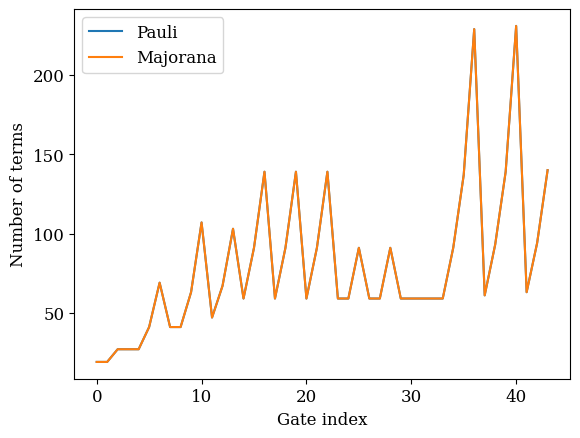

In [ ]:
import matplotlib.pyplot as plt 


plt.plot(result_pauli.n_terms, label="Pauli")
plt.plot(result_majorana.n_terms, label="Majorana")
plt.xlabel("Gate index")
plt.ylabel("Number of terms")
plt.legend()
plt.show()

In [ ]:
print(f"CCSD:                {ccsd_energy}")
print(f"Pauli propagator:    {result_pauli.expectation_value} (n_terms={result_pauli.n_terms[-1]})")
print(f"Majorana propagator: {result_majorana.expectation_value} (n_terms={result_majorana.n_terms[-1]})")

CCSD:                -1.1088730601810635
Pauli propagator:    -1.1088690580909526 (n_terms=140)
Majorana propagator: -1.1088690580909526 (n_terms=140)
